In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
# https://www.statology.org/how-to-use-scipy-probability-distributions-fitting/
# https://pythonguides.com/python-scipy-stats-fit/


In [41]:
no_rtb_no_jokers_hands_df = pd.read_csv("default_hands.csv")
no_rtb_no_jokers_results_df = pd.read_csv("default_results.csv")

RTB_Resultsdf = pd.read_csv("RTB_only_results.csv")
RTB_handsdf = pd.read_csv("RTB_only_hands.csv")

Jokers_NO_RTB_hands_df = pd.read_csv("Jokers_hands.csv")
Jokers_NO_RTB_results_df = pd.read_csv("Jokers_results.csv")

Jokers_And_RTB_results_df = pd.read_csv("RTB_Joker_results.csv")
Jokers_and_RTB_hands_df = pd.read_csv("RTB_Joker_hands.csv")
print(Jokers_NO_RTB_hands_df['hand_type'].value_counts(dropna=False))


hand_type
Two Pair           285189
Pair               262521
Straight            76923
High Card           59613
Flush               54368
Full House          50084
Three of a Kind     42571
Four of a Kind       2737
Straight Flush        677
Name: count, dtype: int64


In [ ]:

defualt_antes = no_rtb_no_jokers_results_df['blinds_played']
RTB_antes = RTB_Resultsdf['blinds_played']
Jokers_antes = Jokers_NO_RTB_results_df['blinds_played']
JokersRTB_antes = Jokers_And_RTB_results_df['blinds_played']

con = 0.95
alpha = 1 - con

#https://pythonguides.com/scipy-confidence-interval/ provided information on how to structure the code.

simulations = {
    "Default": default_antes,
    "RTB Only": RTB_antes,
    "Jokers Only": Jokers_antes,
    "RTB and Jokers": JokersRTB_antes
}


n_resamples = 10000
con = 0.95
alpha = 1 - con

for name, data in simulations.items():
    boot_means = []  

    for _ in range(n_resamples):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))

    lower_bound = np.percentile(boot_means, alpha/2 * 100)
    upper_bound = np.percentile(boot_means, (1 - alpha/2) * 100)
    
    print(f"{name}:")
    print(f"  Mean: {np.mean(data):.4f}")
    print(f"  95% CI: ({lower_bound:.4f}, {upper_bound:.4f})")

Default:
  Mean: 1.1325
  95% CI: (1.1295, 1.1354)
RTB Only:
  Mean: 7.7525
  95% CI: (7.7214, 7.7836)
Jokers Only:
  Mean: 6.2748
  95% CI: (6.2391, 6.3115)
RTB and Jokers:
  Mean: 9.8453
  95% CI: (9.8062, 9.8835)


Text(0.5, 1.0, 'Runs where RTB was used')

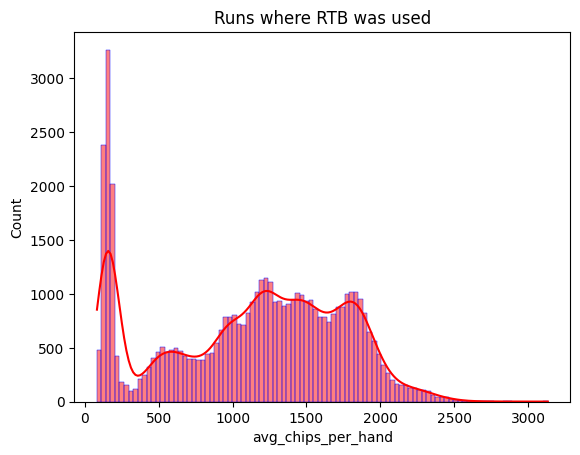

In [6]:
sns.histplot(data = RTB_Resultsdf, x = 'avg_chips_per_hand', color = "red", edgecolor="b", bins=100, kde=True)
plt.title("Runs where RTB was used")

Text(0.5, 1.0, 'Runs where Jokers and RTB')

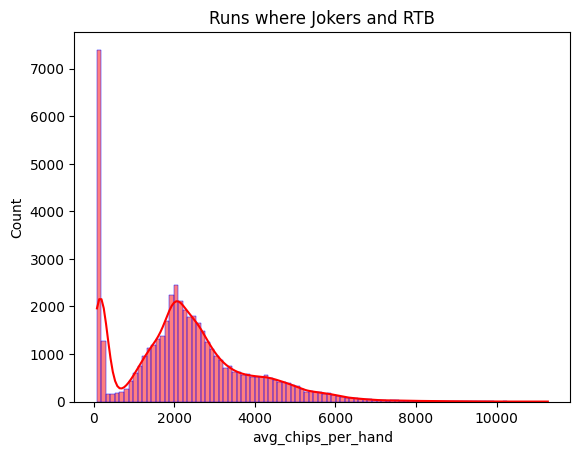

In [7]:
sns.histplot(data =Jokers_And_RTB_results_df, x ='avg_chips_per_hand', color = "red", edgecolor = "b", bins = 100, kde= True)
plt.title("Runs where Jokers and RTB")

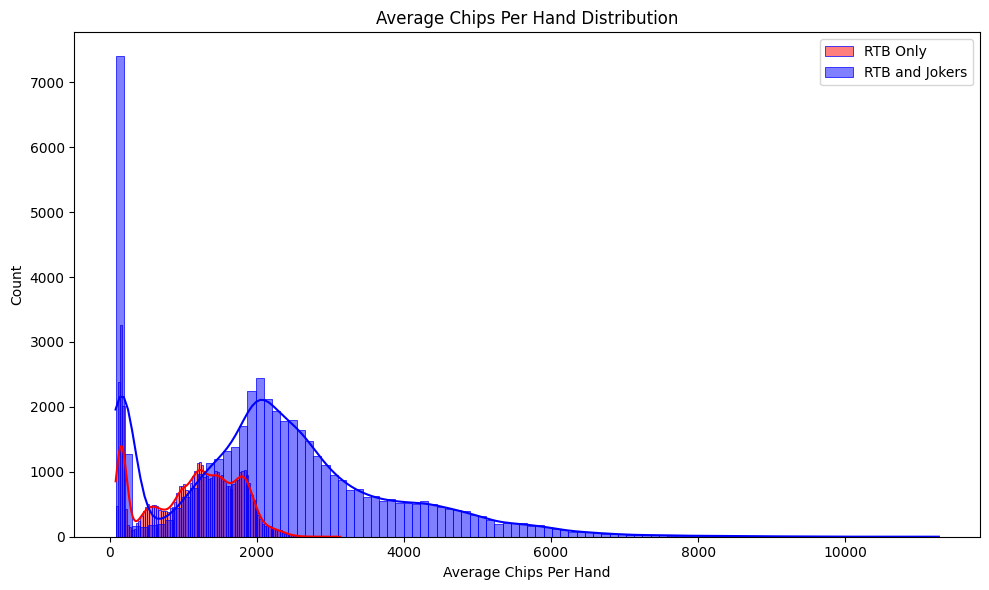

In [ ]:
plt.figure(figsize=(10, 6)) # AI GENERATED BY CLAUDE, ANTHOPIC. 

sns.histplot(data=RTB_Resultsdf, x='avg_chips_per_hand',
             color="red", edgecolor="b", bins=100, kde=True,
             alpha=0.5, label="RTB Only")

sns.histplot(data=Jokers_And_RTB_results_df, x='avg_chips_per_hand',
             color="blue", edgecolor="b", bins=100, kde=True,
             alpha=0.5, label="RTB and Jokers")

plt.title("Average Chips Per Hand Distribution")
plt.xlabel("Average Chips Per Hand")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

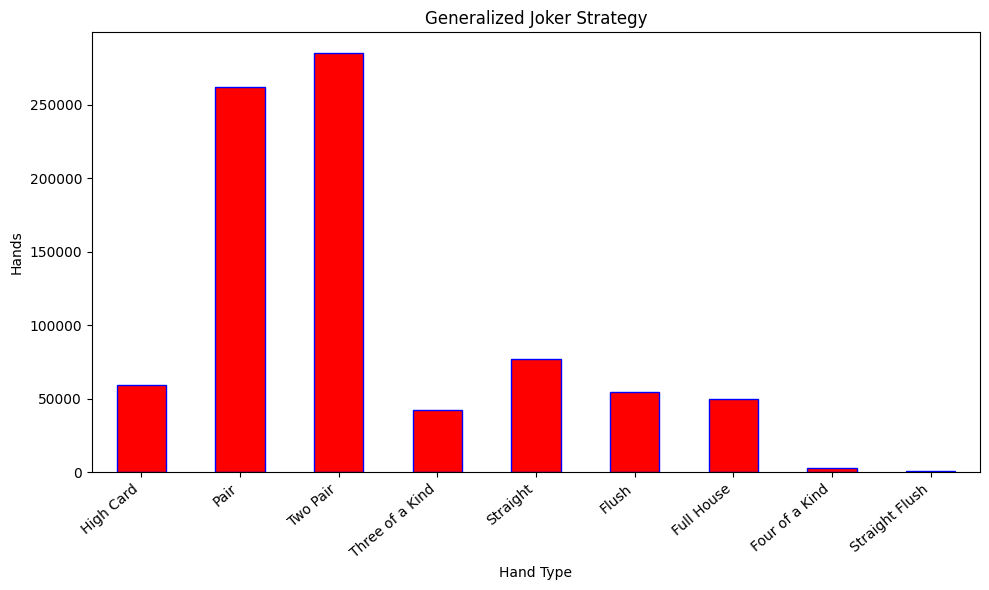

hand_type
High Card           59613
Pair               262521
Two Pair           285189
Three of a Kind     42571
Straight            76923
Flush               54368
Full House          50084
Four of a Kind       2737
Straight Flush        677
Name: count, dtype: int64


In [ ]:

Jokers_NO_RTB_hands_df = pd.read_csv("Jokers_hands.csv")

hand_order = [
    'High Card', 'Pair', 'Two Pair', 'Three of a Kind',
    'Straight', 'Flush', 'Full House', 'Four of a Kind',
    'Straight Flush'
]

hand_counts = Jokers_NO_RTB_hands_df['hand_type'].value_counts()
hand_counts = hand_counts.reindex(hand_order, fill_value=0)

plt.figure(figsize=(10, 6))
hand_counts.plot(kind='bar', color='red', edgecolor='blue')
plt.title("Generalized Joker Strategy")
plt.xlabel("Hand Type")
plt.ylabel("Hands")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(hand_counts)


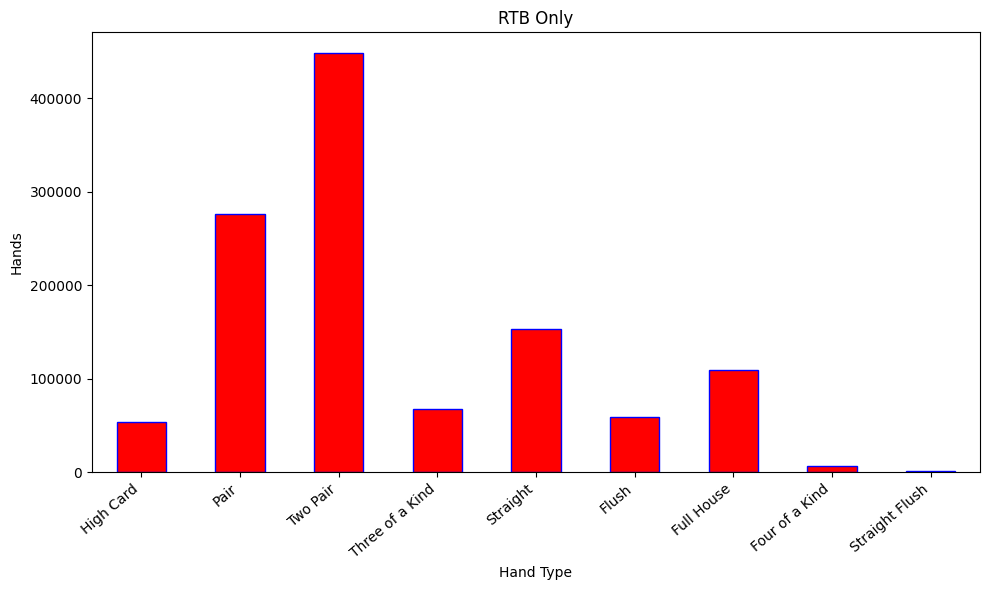

hand_type
High Card           53188
Pair               276589
Two Pair           448295
Three of a Kind     68116
Straight           153081
Flush               58588
Full House         108841
Four of a Kind       6685
Straight Flush       1699
Name: count, dtype: int64


In [131]:

RTB_hand_results = pd.read_csv("RTB_only_hands.csv")

hand_order = [
    'High Card', 'Pair', 'Two Pair', 'Three of a Kind',
    'Straight', 'Flush', 'Full House', 'Four of a Kind',
    'Straight Flush'
]

hand_counts = RTB_hand_results['hand_type'].value_counts()
hand_counts = hand_counts.reindex(hand_order, fill_value=0)

plt.figure(figsize=(10, 6))
hand_counts.plot(kind='bar', color='red', edgecolor='blue')
plt.title("RTB Only")
plt.xlabel("Hand Type")
plt.ylabel("Hands")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(hand_counts)

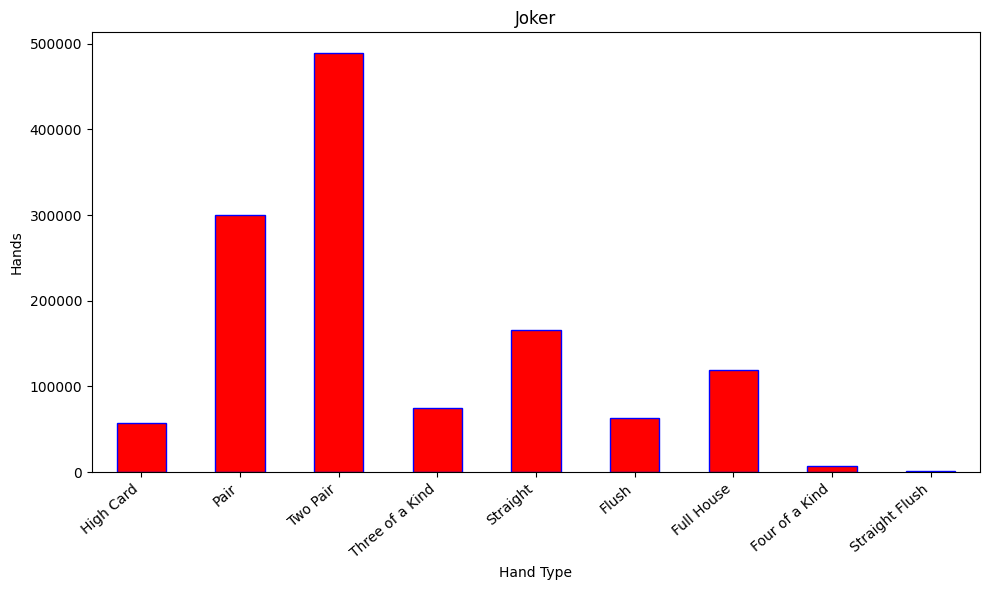

hand_type
High Card           57624
Pair               299729
Two Pair           488670
Three of a Kind     74784
Straight           166432
Flush               63505
Full House         119203
Four of a Kind       7281
Straight Flush       1806
Name: count, dtype: int64


In [136]:
Joker_andRTB_hands = pd.read_csv("RTB_Joker_hands.csv")

hand_order = [
    'High Card', 'Pair', 'Two Pair', 'Three of a Kind',
    'Straight', 'Flush', 'Full House', 'Four of a Kind',
    'Straight Flush'
]

hand_counts = Joker_andRTB_hands['hand_type'].value_counts()
hand_counts = hand_counts.reindex(hand_order, fill_value=0)

plt.figure(figsize=(10, 6))
hand_counts.plot(kind='bar', color='red', edgecolor='blue')
plt.title("Joker")
plt.xlabel("Hand Type")
plt.ylabel("Hands")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(hand_counts)

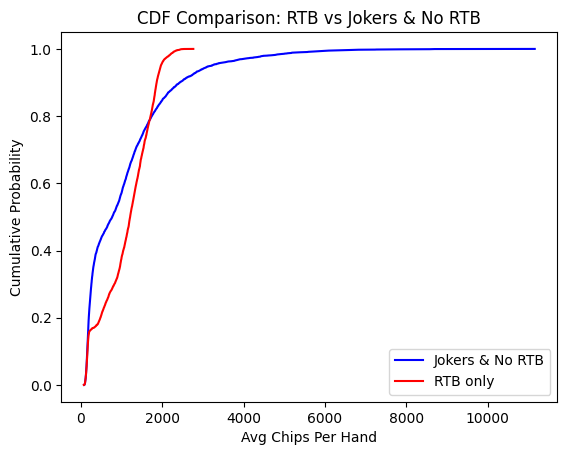

In [82]:

plt.plot(data_sort, cdf_values, label='Jokers & No RTB', color='blue')
plt.plot(data_sort_2, cdf_values_2, label='RTB only', color='red')
plt.xlabel('Avg Chips Per Hand')
plt.ylabel('Cumulative Probability')
plt.title('CDF Comparison: RTB vs Jokers & No RTB')
plt.legend()
plt.show()

Analysis on RTB only

In [15]:

RTB_Resultsdf = pd.read_csv("RTB_only_results.csv")
RTB_handsdf = pd.read_csv("RTB_only_hands.csv")

n = len(RTB_Resultsdf["ante_reached"])
results = RTB_Resultsdf["ante_reached"]

batches = [
    results[i * 5000:(i+ 1) * 5000]
    for i in range(10)
]

batch_means = [np.mean(batch) for batch in batches]

grand_batch_mean = np.mean(batch_means)
batch_variance = np.var(batch_means, ddof=1)
batch_std = np.std(batch_means, ddof=1)

print(f"Grand Batch Mean {grand_batch_mean:.4f}")
print(f"Batch Means {[round(m, 3) for m in batch_means]}")
print(f"Variance: {batch_variance:.4f}")
print(f"Std Dev: {batch_std:.4f}")


Grand Batch Mean 2.9639
Batch Means [np.float64(2.942), np.float64(2.939), np.float64(2.985), np.float64(2.96), np.float64(2.941), np.float64(2.986), np.float64(2.964), np.float64(2.969), np.float64(2.967), np.float64(2.987)]
Variance: 0.0004
Std Dev: 0.0188


In [ ]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html

RTB_Resultsdf["ante_reached"].describe()

count    50000.000000
mean         2.963920
std          1.110731
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: ante_reached, dtype: float64

Analysis on Jokers & No RTB

In [ ]:
Jokers_NO_RTB_hands_df = pd.read_csv("Jokers_hands.csv")
Jokers_NO_RTB_results_df = pd.read_csv("Jokers_results.csv")


n = len(Jokers_NO_RTB_results_df["ante_reached"])
results = Jokers_NO_RTB_results_df["ante_reached"]

batches = [
    results[i * 5000:(i+ 1) * 5000]
    for i in range(10)
]

batch_means = [np.mean(batch) for batch in batches]

grand_batch_mean = np.mean(batch_means)
batch_variance = np.var(batch_means, ddof=1)
batch_std = np.std(batch_means, ddof=1)

print(f"Grand Batch Mean {grand_batch_mean:.4f}")
print(f"Batch Means {[round(m, 3) for m in batch_means]}")
print(f"Variance: {batch_variance:.4f}")
print(f"Std Dev: {batch_std:.4f}")


Grand Batch Mean 2.4562
Batch Means [np.float64(2.471), np.float64(2.442), np.float64(2.427), np.float64(2.473), np.float64(2.457), np.float64(2.447), np.float64(2.443), np.float64(2.49), np.float64(2.443), np.float64(2.468)]
Variance: 0.0004
Std Dev: 0.0190


In [22]:
Jokers_NO_RTB_hands_df["ante_reached"].describe()



count    50000.000000
mean         2.456240
std          1.321711
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: ante_reached, dtype: float64

Analysis on default set

In [11]:

no_rtb_no_jokers_hands_df = pd.read_csv("default_hands.csv")
no_rtb_no_jokers_results_df = pd.read_csv("default_results.csv")

n = len(no_rtb_no_jokers_results_df["ante_reached"])
results = no_rtb_no_jokers_results_df["ante_reached"]

batches = [
    results[i * 5000:(i+ 1) * 5000]
    for i in range(10)
]

batch_means = [np.mean(batch) for batch in batches]

grand_batch_mean = np.mean(batch_means)
batch_variance = np.var(batch_means, ddof=1)
batch_std = np.std(batch_means, ddof=1)

print(f"Grand Batch Mean {grand_batch_mean:.4f}")
print(f"Batch Means {[round(m, 3) for m in batch_means]}")
print(f"Variance: {batch_variance:.4f}")
print(f"Std Dev: {batch_std:.4f}")


Grand Batch Mean 1.1325
Batch Means [np.float64(1.13), np.float64(1.129), np.float64(1.129), np.float64(1.143), np.float64(1.125), np.float64(1.135), np.float64(1.135), np.float64(1.134), np.float64(1.129), np.float64(1.135)]
Variance: 0.0000
Std Dev: 0.0051


In [21]:
no_rtb_no_jokers_results_df["ante_reached"].describe()

count    50000.000000
mean         1.132500
std          0.339037
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: ante_reached, dtype: float64

Analysis on Jokers & RTB runs

In [13]:
Jokers_And_RTB_results_df = pd.read_csv("RTB_Joker_results.csv")
Jokers_and_RTB_hands_df = pd.read_csv("RTB_Joker_hands.csv")

n = len(Jokers_And_RTB_results_df["ante_reached"])
results = Jokers_And_RTB_results_df["ante_reached"]

batches = [
    results[i * 5000:(i+ 1) * 5000]
    for i in range(10)
]

batch_means = [np.mean(batch) for batch in batches]

grand_batch_mean = np.mean(batch_means)
batch_variance = np.var(batch_means, ddof=1)
batch_std = np.std(batch_means, ddof=1)

print(f"Grand Batch Mean {grand_batch_mean:.4f}")
print(f"Batch Means {[round(m, 3) for m in batch_means]}")
print(f"Variance: {batch_variance:.4f}")
print(f"Std Dev: {batch_std:.4f}")


Grand Batch Mean 3.6246
Batch Means [np.float64(3.613), np.float64(3.632), np.float64(3.639), np.float64(3.632), np.float64(3.632), np.float64(3.657), np.float64(3.598), np.float64(3.623), np.float64(3.619), np.float64(3.603)]
Variance: 0.0003
Std Dev: 0.0176


In [19]:
Jokers_And_RTB_results_df["ante_reached"].describe()

count    50000.000000
mean         3.624620
std          1.359892
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          6.000000
Name: ante_reached, dtype: float64

Aggregate Comparisons and statistical tests

In [50]:
from scipy.stats import kruskal

ante_default = no_rtb_no_jokers_results_df["ante_reached"].to_numpy()
ante_rtb_only = RTB_Resultsdf["ante_reached"].to_numpy()
ante_rtb_and_jokers = Jokers_And_RTB_results_df["ante_reached"].to_numpy()
ante_jokers_only = Jokers_NO_RTB_results_df["ante_reached"].to_numpy()

result = kruskal(ante_default, ante_rtb_only, ante_rtb_and_jokers, ante_jokers_only)
print(f"H statistic: {result.statistic}")
print(f"P-value: {result.pvalue}")

print(f"Smallest float64: {np.finfo(np.float64).tiny}")

H statistic: 79270.89304186121
P-value: 0.0
Smallest float64: 2.2250738585072014e-308


In [57]:
print("RTB Only counts:", rtb_c)
print("Jokers Only counts:", jokers_c)
print("RTB and Jokers counts:", rtb_jokers_c)
print("defaults:", defaults_c)

RTB Only counts: [ 9109  4421 15664 20777    29     0]
Jokers Only counts: [18880  5438 12186 11048  2382    66]
RTB and Jokers counts: [ 8763   547  4473 23577 12193   447]
defaults: [43375  6625     0     0     0     0     0     0]


In [55]:


antes = np.arange(1, 7)  # antes 1 through 5 only
rtb_c = np.array([np.sum(ante_rtb_only == a) for a in antes])
jokers_c = np.array([np.sum(ante_jokers_only == a) for a in antes])
rtb_jokers_c = np.array([np.sum(ante_rtb_and_jokers == a) for a in antes])

table = np.array([rtb_c, jokers_c, rtb_jokers_c])

print("RTB Only counts:", rtb_c)
print("Jokers Only counts:", jokers_c)
print("RTB and Jokers counts:", rtb_jokers_c)

res = chi2_contingency(table)
print(f"Chi-square statistic: {res.statistic}")
print(f"P-value: {res.pvalue}")
print(f"Degrees of freedom: {res.dof}")

#https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_chi2_contingency.html#hypothesis-chi2-contingency



RTB Only counts: [ 9109  4421 15664 20777    29     0]
Jokers Only counts: [18880  5438 12186 11048  2382    66]
RTB and Jokers counts: [ 8763   547  4473 23577 12193   447]
Chi-square statistic: 37781.97324890669
P-value: 0.0
Degrees of freedom: 10


Text(0, 0.5, 'Runs')

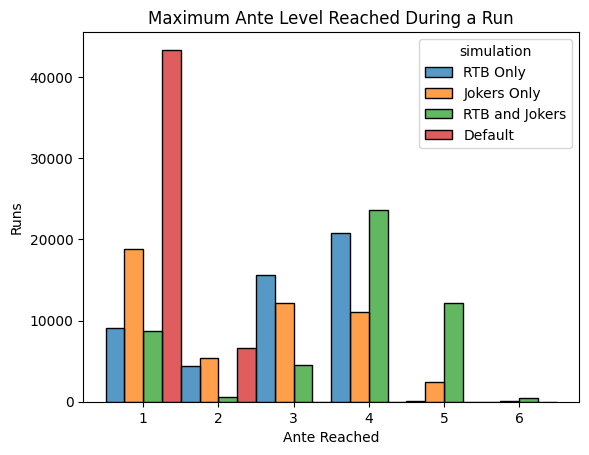

In [ ]:
combined_df = pd.DataFrame({
    "ante_reached": np.concatenate([ante_rtb_only, ante_jokers_only, 
                                     ante_rtb_and_jokers]),
    "simulation": (["RTB Only"] * len(ante_rtb_only) +
                   ["Jokers Only"] * len(ante_jokers_only) +
                   ["RTB and Jokers"] * len(ante_rtb_and_jokers))
})

sns.histplot(data=combined_df, x="ante_reached", hue="simulation", multiple = "dodge", discrete = True)
plt.title("Maximum Ante Level Reached During a Run")
plt.xlabel("Ante Reached")
plt.ylabel("Runs")

#Claude AI helped with the combined DF part, as I was not aware this was necessary to combine the dfs for seaborn. 

Text(0, 0.5, 'Runs')

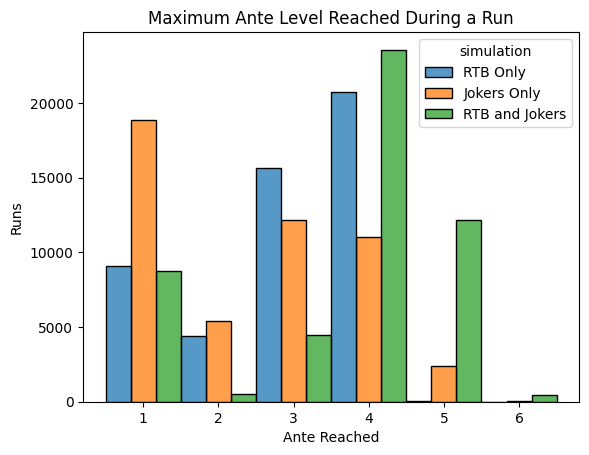

In [ ]:
combined_df = pd.DataFrame({
    "ante_reached": np.concatenate([ante_rtb_only, ante_jokers_only, 
                                     ante_rtb_and_jokers]),
    "simulation": (["RTB Only"] * len(ante_rtb_only) +
                   ["Jokers Only"] * len(ante_jokers_only) +
                   ["RTB and Jokers"] * len(ante_rtb_and_jokers))
})

sns.histplot(data=combined_df, x="ante_reached", hue="simulation", multiple = "dodge", discrete = True)
plt.title("Maximum Ante Level Reached During a Run")
plt.xlabel("Ante Reached")
plt.ylabel("Runs")

#Claude AI helped with the combined DF part, as I was not aware this was necessary to combine the dfs for seaborn. 

Text(0, 0.5, 'Runs')

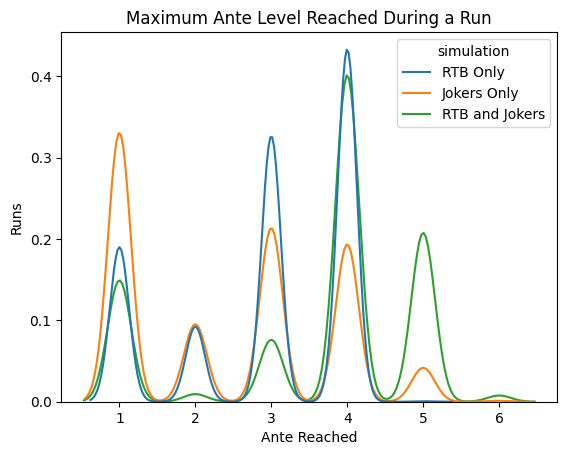

In [93]:
combined_df = pd.DataFrame({
    "ante_reached": np.concatenate([ante_rtb_only, ante_jokers_only, 
                                     ante_rtb_and_jokers]),
    "simulation": (["RTB Only"] * len(ante_rtb_only) +
                   ["Jokers Only"] * len(ante_jokers_only) +
                   ["RTB and Jokers"] * len(ante_rtb_and_jokers))
})

sns.kdeplot(data=combined_df, x="ante_reached", hue="simulation",)
plt.title("Maximum Ante Level Reached During a Run")
plt.xlabel("Ante Reached")
plt.ylabel("Runs")

In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html

#Is a non paramatric is a test of the null hypothesis that the distribution underlying sample x is the same as the distribution underlying sample Y. BUT, We also tested to see if one distribution (X) was greater than distribution (Y)
#NaNs were returned for defaults because, in laimens term, of how different hte distribution is
from scipy.stats import mannwhitneyu

from scipy.stats import mannwhitneyu

rtb_only_antes = combined_df.loc[combined_df['simulation'] == "RTB Only", "ante_reached"]
jokers_only_antes = combined_df.loc[combined_df['simulation'] == "Jokers Only", "ante_reached"]
rtb_jokers_antes = combined_df.loc[combined_df['simulation'] == "RTB and Jokers", "ante_reached"]
default_antes = combined_df.loc[combined_df['simulation'] == "Default", "ante_reached"]

# primary comparisons
print("RTB Only vs Jokers Only:")
print(mannwhitneyu(rtb_only_antes, jokers_only_antes, alternative="two-sided", method="asymptotic"))

print("\nRTB and Jokers vs Jokers Only:")
print(mannwhitneyu(rtb_jokers_antes, jokers_only_antes, alternative="two-sided", method="asymptotic"))

# secondary comparisons
print("\nRTB Only vs RTB and Jokers:")
print(mannwhitneyu(rtb_only_antes, rtb_jokers_antes, alternative="two-sided", method="asymptotic"))

print("\nDefault vs RTB Only:")
print(mannwhitneyu(default_antes, rtb_only_antes, alternative="two-sided", method="asymptotic"))

print("\nDefault vs Jokers Only:")
print(mannwhitneyu(default_antes, jokers_only_antes, alternative="two-sided", method="asymptotic"))

print("\nDefault vs RTB and Jokers:")
print(mannwhitneyu(default_antes, rtb_jokers_antes, alternative="two-sided", method="asymptotic"))

RTB Only vs Jokers Only:
MannwhitneyuResult(statistic=np.float64(1532465346.0), pvalue=np.float64(0.0))

RTB and Jokers vs Jokers Only:
MannwhitneyuResult(statistic=np.float64(1838118580.0), pvalue=np.float64(0.0))

RTB Only vs RTB and Jokers:
MannwhitneyuResult(statistic=np.float64(793285120.0), pvalue=np.float64(0.0))

Default vs RTB Only:
MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))

Default vs Jokers Only:
MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))

Default vs RTB and Jokers:
MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))


C:\Users\evanm\AppData\Local\Temp\ipykernel_34124\3711597908.py:26: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(mannwhitneyu(default_antes, rtb_only_antes, alternative="two-sided", method="asymptotic"))
C:\Users\evanm\AppData\Local\Temp\ipykernel_34124\3711597908.py:29: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(mannwhitneyu(default_antes, jokers_only_antes, alternative="two-sided", method="asymptotic"))
C:\Users\evanm\AppData\Local\Temp\ipykernel_34124\3711597908.py:32: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(mannwhitneyu(default_antes, rtb_jokers_antes, alternative="two-sided", method="asymptotic"))


In [97]:
print("RTB Only vs Jokers Only:")
print(mannwhitneyu(rtb_only_antes, jokers_only_antes, alternative="greater", method="asymptotic"))

print("\nRTB_and Jokers vs Jokers Only:")
print(mannwhitneyu(rtb_jokers_antes, jokers_only_antes, alternative="greater", method="asymptotic"))

# secondary comparisons
print("\nRTB Only vs RTB and Jokers:")
print(mannwhitneyu(rtb_only_antes, rtb_jokers_antes, alternative="greater", method="asymptotic"))


RTB Only vs Jokers Only:
MannwhitneyuResult(statistic=np.float64(1532465346.0), pvalue=np.float64(0.0))

RTB_and Jokers vs Jokers Only:
MannwhitneyuResult(statistic=np.float64(1838118580.0), pvalue=np.float64(0.0))

RTB Only vs RTB and Jokers:
MannwhitneyuResult(statistic=np.float64(793285120.0), pvalue=np.float64(1.0))


In [98]:
ante_values = np.arange(1, 9)  # antes 1 through 8

simulations = {
    "Default": ante_default,
    "RTB Only": ante_rtb_only,
    "Jokers Only": ante_jokers_only,
    "RTB and Jokers": ante_rtb_and_jokers
}

# build probability table
prob_table = {}
for sim_name, sim_data in simulations.items():
    probs = [np.sum(sim_data == a) / len(sim_data) for a in ante_values]
    prob_table[sim_name] = probs

prob_df = pd.DataFrame(prob_table, index=[f"Ante {a}" for a in ante_values])

# round for readability
prob_df = prob_df.round(4)

print(prob_df)

        Default  RTB Only  Jokers Only  RTB and Jokers
Ante 1   0.8675    0.1822       0.3776          0.1753
Ante 2   0.1325    0.0884       0.1088          0.0109
Ante 3   0.0000    0.3133       0.2437          0.0895
Ante 4   0.0000    0.4155       0.2210          0.4715
Ante 5   0.0000    0.0006       0.0476          0.2439
Ante 6   0.0000    0.0000       0.0013          0.0089
Ante 7   0.0000    0.0000       0.0000          0.0000
Ante 8   0.0000    0.0000       0.0000          0.0000


In [103]:
ante_values = np.arange(1, 9)  # antes 1 through 8

simulations = {
    "Default": ante_default,
    "RTB Only": ante_rtb_only,
    "Jokers Only": ante_jokers_only,
    "RTB and Jokers": ante_rtb_and_jokers
}

# build probability table
prob_table = {}
for sim_name, sim_data in simulations.items():
    probs = [np.sum(sim_data == a) / len(sim_data) for a in ante_values]
    prob_table[sim_name] = probs

prob_df = pd.DataFrame(prob_table, index=[f"Ante {a}" for a in ante_values])

# round for readability
prob_df = prob_df.round(4)


In [104]:
no_rtb_no_jokers_hands_df = pd.read_csv("default_hands.csv")
no_rtb_no_jokers_results_df = pd.read_csv("default_results.csv")

RTB_Resultsdf = pd.read_csv("RTB_only_results.csv")
RTB_handsdf = pd.read_csv("RTB_only_hands.csv")

Jokers_NO_RTB_hands_df = pd.read_csv("Jokers_hands.csv")
Jokers_NO_RTB_results_df = pd.read_csv("Jokers_results.csv")

Jokers_And_RTB_results_df = pd.read_csv("RTB_Joker_results.csv")
Jokers_and_RTB_hands_df = pd.read_csv("RTB_Joker_hands.csv")

ante_values = np.arange(1, 9)

simulations = {
    "Default": no_rtb_no_jokers_hands_df['tot_Jokers_mults'],
    "RTB Only": RTB_handsdf['add_mult_from_RTB'],
    "Jokers Only": Jokers_NO_RTB_hands_df['tot_Jokers_mults'],
    "RTB and Jokers": Jokers_and_RTB_hands_df['tot_Jokers_mults']
}

prob_table = {}
for sim_name, sim_data in simulations.items():
    probs = [np.sum(sim_data == a) / len(sim_data) for a in ante_values]
    prob_table[sim_name] = probs

prob_df = pd.DataFrame(prob_table, index=[f"Ante {a}" for a in ante_values])


print(prob_df)

         Default  RTB Only  Jokers Only  RTB and Jokers
Ante 1  0.071500  0.042925     0.030055        0.008195
Ante 2  0.655863  0.041284     0.278415        0.077686
Ante 3  0.050627  0.039391     0.022062        0.029649
Ante 4  0.217869  0.037471     0.099863        0.054232
Ante 5  0.000000  0.035878     0.055238        0.031937
Ante 6  0.000000  0.034998     0.035659        0.028382
Ante 7  0.003380  0.034216     0.019738        0.024961
Ante 8  0.000760  0.033574     0.037257        0.022092


In [10]:
# merge hands with results to get ante information.
RTB_jokers_merged = Jokers_and_RTB_hands_df.merge(
    Jokers_And_RTB_results_df[['run_id', 'ante_reached']], 
    on='run_id', 
    how='left'
)

jokers_only_merged = Jokers_NO_RTB_hands_df.merge(
    Jokers_NO_RTB_results_df[['run_id', 'ante_reached']], 
    on='run_id', 
    how='left'
)

RTB_only_merged = RTB_handsdf.merge(
    RTB_Resultsdf[['run_id', 'ante_reached']], 
    on='run_id', 
    how='left'
)

# group by ante and calculate mean joker mult per hand
rtb_jokers_avg = RTB_jokers_merged.groupby('ante_reached')['tot_Jokers_mults'].mean()
jokers_only_avg = jokers_only_merged.groupby('ante_reached')['tot_Jokers_mults'].mean()
rtb_only_avg = RTB_only_merged.groupby('ante_reached')['add_mult_from_RTB'].mean()

avg_mult_df = pd.DataFrame({
    "RTB Only": rtb_only_avg,
    "Jokers Only": jokers_only_avg,
    "RTB and Jokers": rtb_jokers_avg
}, index=np.arange(1, 9))

print(avg_mult_df)

#This was AI generated as I couldn't figure out how to do this table. 

    RTB Only  Jokers Only  RTB and Jokers
1   0.213140     2.358786        2.096003
2   3.656780     5.102649        6.704888
3   9.591635    10.211456       13.498192
4  14.146724    13.925924       20.756811
5  19.342357    16.257756       24.170475
6        NaN    24.612185       28.106617
7        NaN          NaN             NaN
8        NaN          NaN             NaN


In [38]:
df = pd.read_csv("RTB_Joker_results.csv")
df = df[df["use_rtb"] == True]

df["jokers_parsed"] = df["jokers"].str.strip("[]").str.replace("'", "").str.split(", ").apply(lambda js: [j for j in js if j != "RTB"])

df["joker_group"] = df["jokers_parsed"].apply(lambda js: tuple(sorted(js)))

groups = (df.groupby(["joker_group"])["avg_chips_per_hand"]
          .agg(avg_chips="mean", n_runs = "count")
          .reset_index()
          .query("n_runs >= 10")
          .sort_values("avg_chips", ascending = False)
)
groups["joker_group"] = groups["joker_group"].apply(lambda t: ", ".join(t)) 
groups["avg_chips"] = groups["avg_chips"].round(1)

print(groups.to_string(index = False))
print(df["use_rtb"].value_counts())
print(df[~df["jokers"].str.contains("RTB", na=False)]["jokers"].value_counts())



                                               joker_group  avg_chips  n_runs
                  Banner, Crafty Joker, Misprint, Odd Todd     6082.1      12
               Banner, Clever Joker, Odd Todd, Willy Joker     5703.3      10
               Banner, Devious Joker, Half Joker, Odd Todd     5675.8      10
                  Banner, Odd Todd, Sly joker, Willy Joker     5205.2      10
                 Banner, Odd Todd, Scary Face, Willy Joker     4968.9      10
                  Banner, Jolly Joker, Odd Todd, Sly joker     4968.6      10
               Banner, Even Steven, Lusty Joker, Sly joker     4921.3      10
                  Banner, Misprint, Scary Face, Zany Joker     4783.7      10
           Banner, Clever Joker, Devious Joker, Scary Face     4776.4      12
          Banner, Clever Joker, Devious Joker, Willy Joker     4770.5      12
               Banner, Crafty Joker, Jolly Joker, Odd Todd     4616.7      10
                Banner, Crafty Joker, Odd Todd, Scary Face     4

0        ['RTB', 'Odd Todd', 'Wrathful Joker', 'Lusty J...
1        ['RTB', 'Greedy Joker', 'Sly joker', 'Odd Todd...
2        ['RTB', 'Mad joker', 'Joker', 'Zany Joker', 'C...
3        ['RTB', 'Shoot The Moon', 'Lusty Joker', 'Scar...
4                                                       []
                               ...                        
49995                                                   []
49996    ['RTB', 'Joker', 'Mystic Summit', 'Odd Todd', ...
49997                                                   []
49998    ['RTB', 'Lusty Joker', 'Mystic Summit', 'Mad j...
49999    ['RTB', 'Wrathful Joker', 'Lusty Joker', 'Misp...
Name: jokers, Length: 50000, dtype: str